In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="white", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 16,
    "axes.grid": False,
})

In [2]:
FILE_PATH = "/Users/saranya.pal/Desktop/float-categorisation/data/tfidf_features_with_gl_code.csv"
df = pd.read_csv(FILE_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (3078, 29)
Columns: ['aggregated_text', 'auto', 'card', 'cypress', 'cypress hill', 'cypress hill use', 'cypress portfolio', 'cypress portfolio 20', 'financial', 'limit', 'manage', 'match renewal', 'match renewal requirement', 'need', 'passtime', 'platform', 'product', 'product manage', 'product manage cypress', 'purchase', 'renewal', 'spring', 'update', 'update card', 'update card limit', 'use', 'use passtime', 'use passtime platform', 'gl_code']


,aggregated_text,auto,card,cypress,cypress hill,cypress hill use,cypress portfolio,cypress portfolio 20,financial,limit,...,purchase,renewal,spring,update,update card,update card limit,use,use passtime,use passtime platform,gl_code
0,purchase alberta insurance council license ren...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.357911,0.933756,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1320 prepaid expense
1,purchase articulate global llc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1320 prepaid expense
2,purchase asana.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1320 prepaid expense


# TF-IDF Feature Analysis

## How the 27 TF-IDF Features Were Created
The `aggregated_text` column (produced by joining spaCy-cleaned `transaction type`, `payee`, and `transaction detail`) was vectorised using `TfidfVectorizer` with these parameters:

| Parameter | Value |
|---|---|
| `ngram_range` | (1, 3) — unigrams, bigrams, trigrams |
| `max_features` | 27 — top 27 features by term frequency |
| `max_df` | 0.95 — ignore terms in >95% of docs |
| `min_df` | 2 — ignore terms in <2 docs |
| `sublinear_tf` | True — apply `1 + log(tf)` scaling |
| `norm` | l2 — row-wise L2 normalisation |
| `use_idf` / `smooth_idf` | True / True |

Each of the 27 columns is a continuous TF-IDF weight (0..1 range after L2 norm). The target is `gl_code` (categorical, 11 classes).

In [3]:
# ── Separate features and target ────────────────────────────────────────────
TARGET = "gl_code"
TFIDF_COLS = [c for c in df.columns if c not in ["aggregated_text", TARGET]]
print(f"TF-IDF features ({len(TFIDF_COLS)}): {TFIDF_COLS}")
print(f"Target: {TARGET}  ({df[TARGET].nunique()} classes)")
print(f"\nBasic statistics:")
display(df[TFIDF_COLS].describe().T.style.format("{:.4f}").background_gradient(cmap="YlOrRd", axis=0))

TF-IDF features (27): ['auto', 'card', 'cypress', 'cypress hill', 'cypress hill use', 'cypress portfolio', 'cypress portfolio 20', 'financial', 'limit', 'manage', 'match renewal', 'match renewal requirement', 'need', 'passtime', 'platform', 'product', 'product manage', 'product manage cypress', 'purchase', 'renewal', 'spring', 'update', 'update card', 'update card limit', 'use', 'use passtime', 'use passtime platform']
Target: gl_code  (11 classes)

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
auto,3078.0000,0.0305,0.0752,0.0000,0.0000,0.0000,0.0000,0.9355
card,3078.0000,0.0480,0.1339,0.0000,0.0000,0.0000,0.0000,0.9733
cypress,3078.0000,0.0492,0.1117,0.0000,0.0000,0.0000,0.0000,0.3027
cypress hill,3078.0000,0.0290,0.0660,0.0000,0.0000,0.0000,0.0000,0.1788
cypress hill use,3078.0000,0.0290,0.0660,0.0000,0.0000,0.0000,0.0000,0.1788
cypress portfolio,3078.0000,0.0290,0.0660,0.0000,0.0000,0.0000,0.0000,0.1788
cypress portfolio 20,3078.0000,0.0290,0.0660,0.0000,0.0000,0.0000,0.0000,0.1788
financial,3078.0000,0.0346,0.0886,0.0000,0.0000,0.0000,0.0000,1.0000
limit,3078.0000,0.0296,0.0698,0.0000,0.0000,0.0000,0.0000,0.9357
manage,3078.0000,0.0293,0.0679,0.0000,0.0000,0.0000,0.0000,0.9358


## 1. TF-IDF Feature Sparsity & Distribution

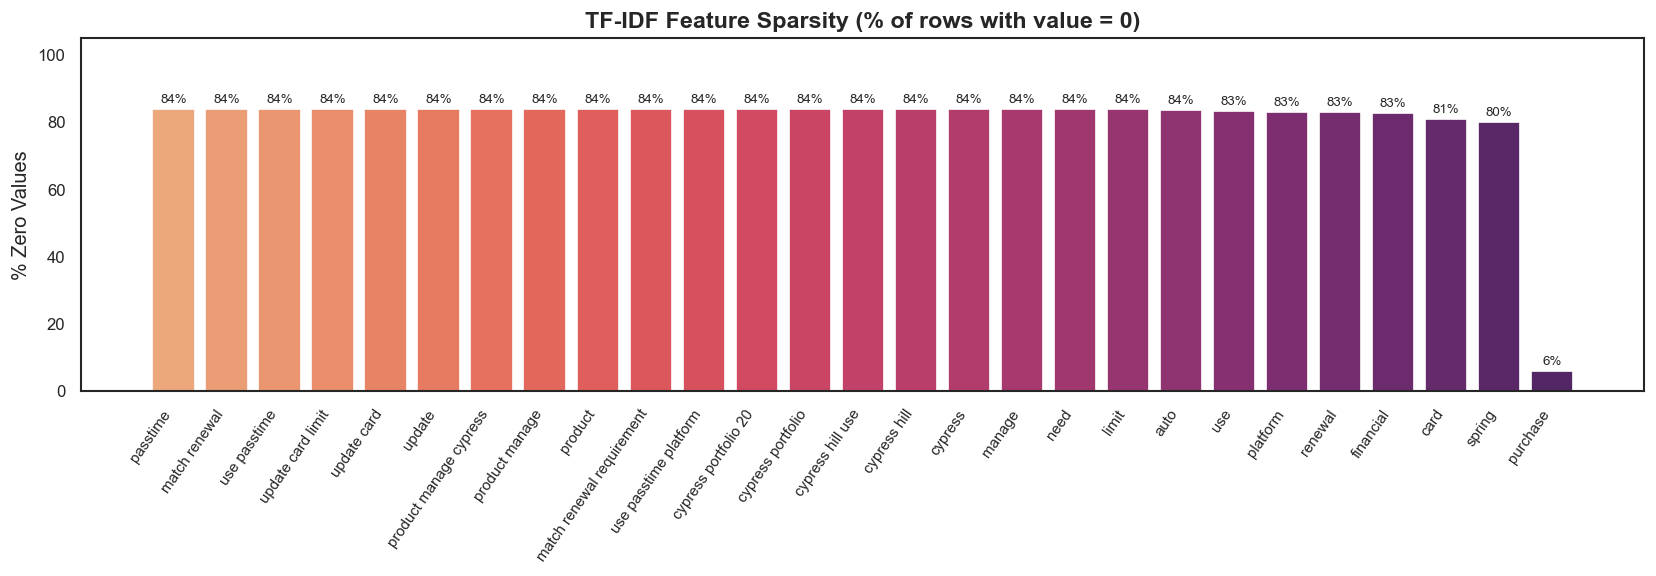

Average sparsity across all TF-IDF features: 80.5%
Most sparse : passtime (83.8% zeros)
Least sparse: purchase (5.8% zeros)


In [5]:
# ── Sparsity: % of zeros per feature ────────────────────────────────────────
sparsity = (df[TFIDF_COLS] == 0).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(sparsity)), sparsity.values * 100,
              color=sns.color_palette("flare", len(sparsity)), edgecolor="white")
ax.set_xticks(range(len(sparsity)))
ax.set_xticklabels(sparsity.index, rotation=55, ha="right", fontsize=9)
ax.set_ylabel("% Zero Values")
ax.set_title("TF-IDF Feature Sparsity (% of rows with value = 0)", fontsize=14, fontweight="bold")
ax.set_ylim(0, 105)

for bar, val in zip(bars, sparsity.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.0%}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Average sparsity across all TF-IDF features: {sparsity.mean():.1%}")
print(f"Most sparse : {sparsity.index[0]} ({sparsity.iloc[0]:.1%} zeros)")
print(f"Least sparse: {sparsity.index[-1]} ({sparsity.iloc[-1]:.1%} zeros)")

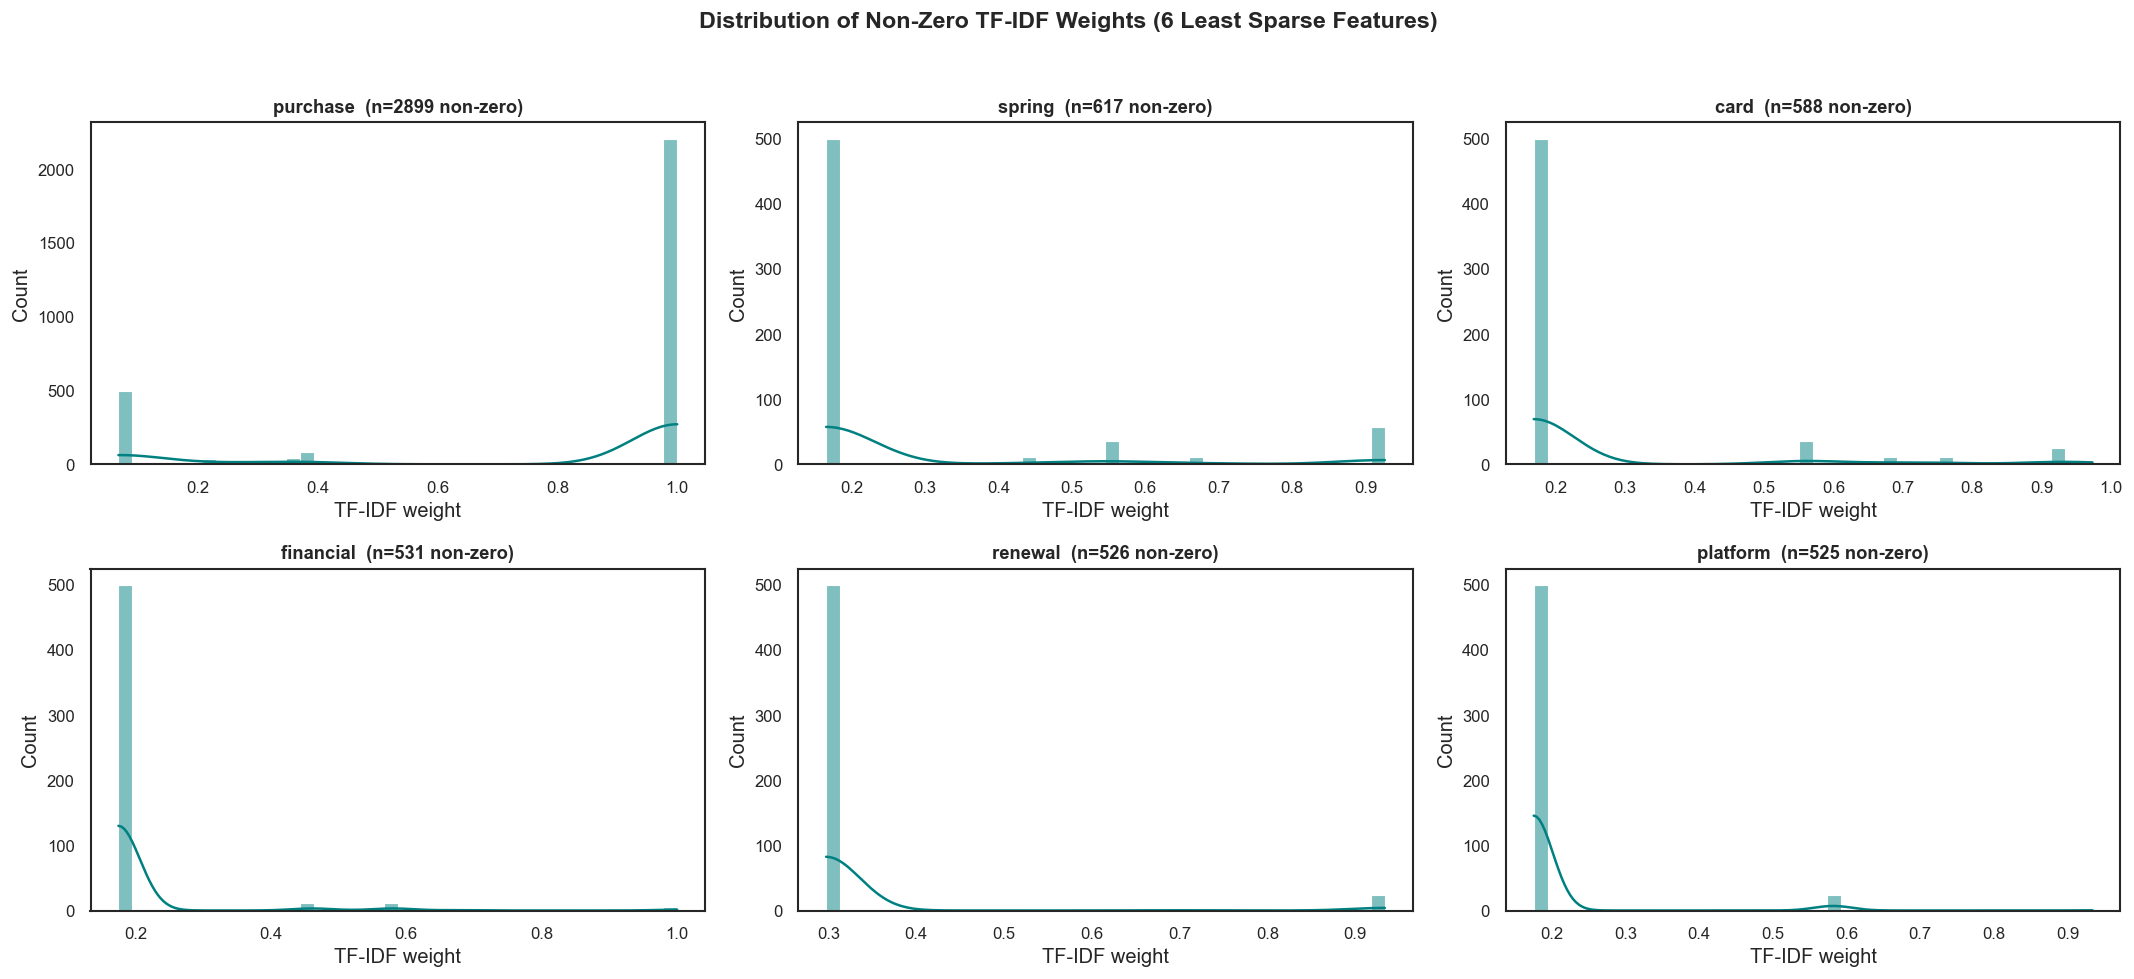

In [6]:
# ── Distribution of non-zero TF-IDF values (histograms for top-6 least sparse) ──
least_sparse_6 = (df[TFIDF_COLS] == 0).mean().sort_values(ascending=True).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

for ax, col in zip(axes, least_sparse_6):
    nonzero = df[col][df[col] > 0]
    sns.histplot(nonzero, bins=40, kde=True, ax=ax, color="teal", edgecolor="white")
    ax.set_title(f"{col}  (n={len(nonzero)} non-zero)", fontsize=11, fontweight="bold")
    ax.set_xlabel("TF-IDF weight")

fig.suptitle("Distribution of Non-Zero TF-IDF Weights (6 Least Sparse Features)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2. Correlation Between TF-IDF Features

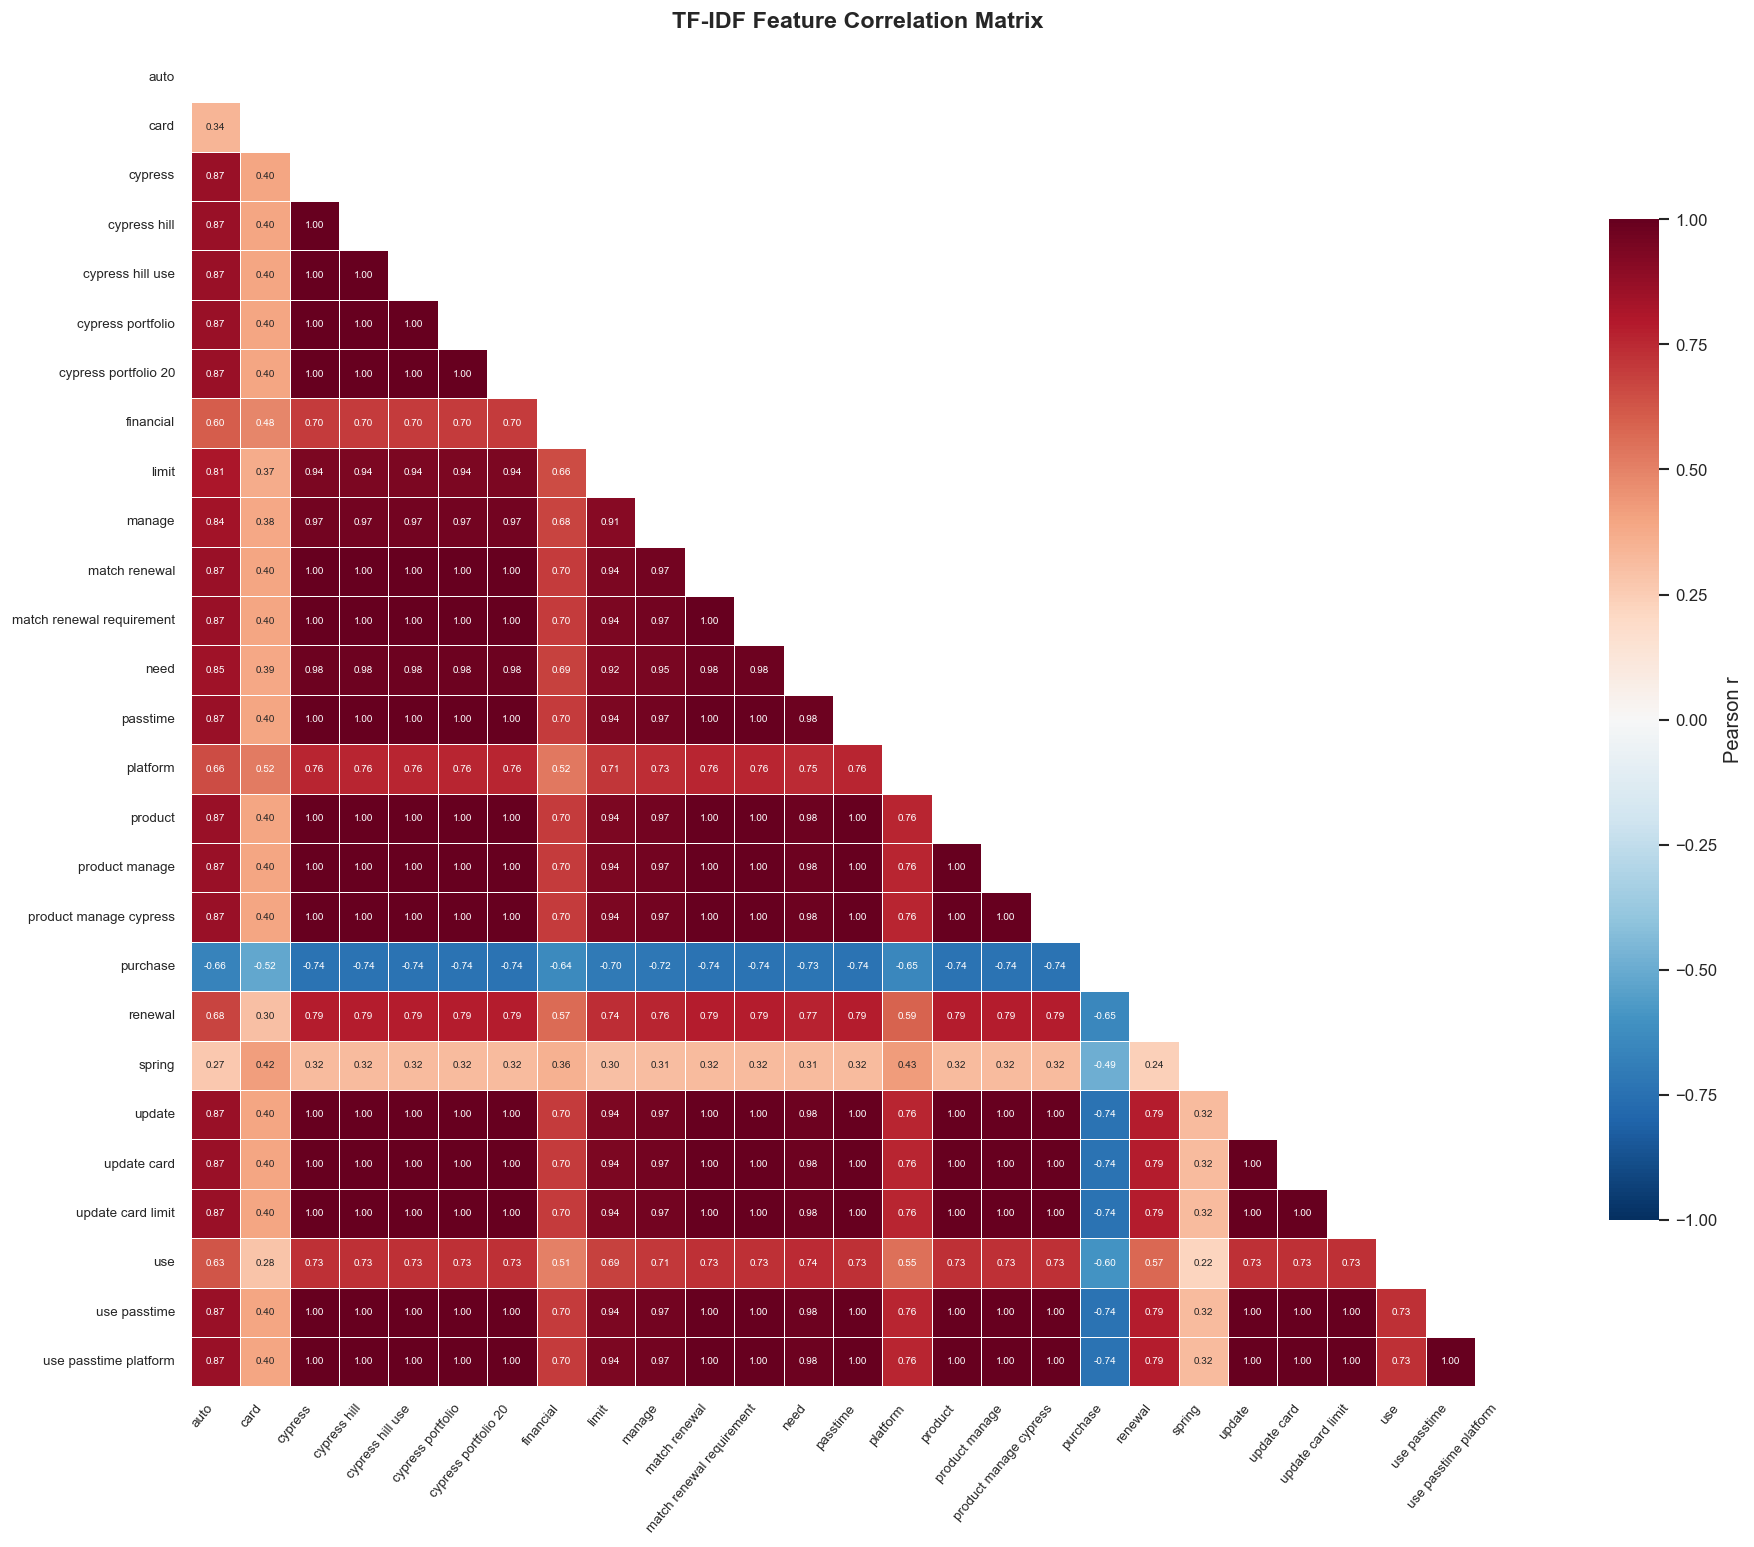

Notable TF-IDF correlations (|r| > 0.3):  346 pairs


,Feature 1,Feature 2,r
0,use passtime platform,use passtime,1.000
1,update card limit,passtime,1.000
2,product,cypress portfolio,1.000
3,product,cypress portfolio 20,1.000
4,update card limit,product manage,1.000
5,product,match renewal,1.000
6,product,match renewal requirement,1.000
7,product,passtime,1.000
8,update card limit,product,1.000
9,product manage,cypress,1.000


In [7]:
# ── Pearson correlation heatmap between TF-IDF features ─────────────────────
corr = df[TFIDF_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.4, ax=ax,
    annot_kws={"size": 6}, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
)
ax.set_title("TF-IDF Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=50, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Notable pairs
strong = corr.where(~mask).stack().reset_index()
strong.columns = ["Feature 1", "Feature 2", "r"]
strong = strong[strong["r"].abs() > 0.3].sort_values("r", key=abs, ascending=False)
if len(strong):
    print(f"Notable TF-IDF correlations (|r| > 0.3):  {len(strong)} pairs")
    display(strong.reset_index(drop=True).style.format({"r": "{:.3f}"}).background_gradient(
        cmap="RdBu_r", subset=["r"], vmin=-1, vmax=1))
else:
    print("No TF-IDF feature pairs with |r| > 0.3")

## 3. TF-IDF Feature Association with GL Code (η²)

**Eta-squared (η²)** quantifies the proportion of variance in each TF-IDF feature
explained by the GL code class. Higher η² signals stronger discriminative power.

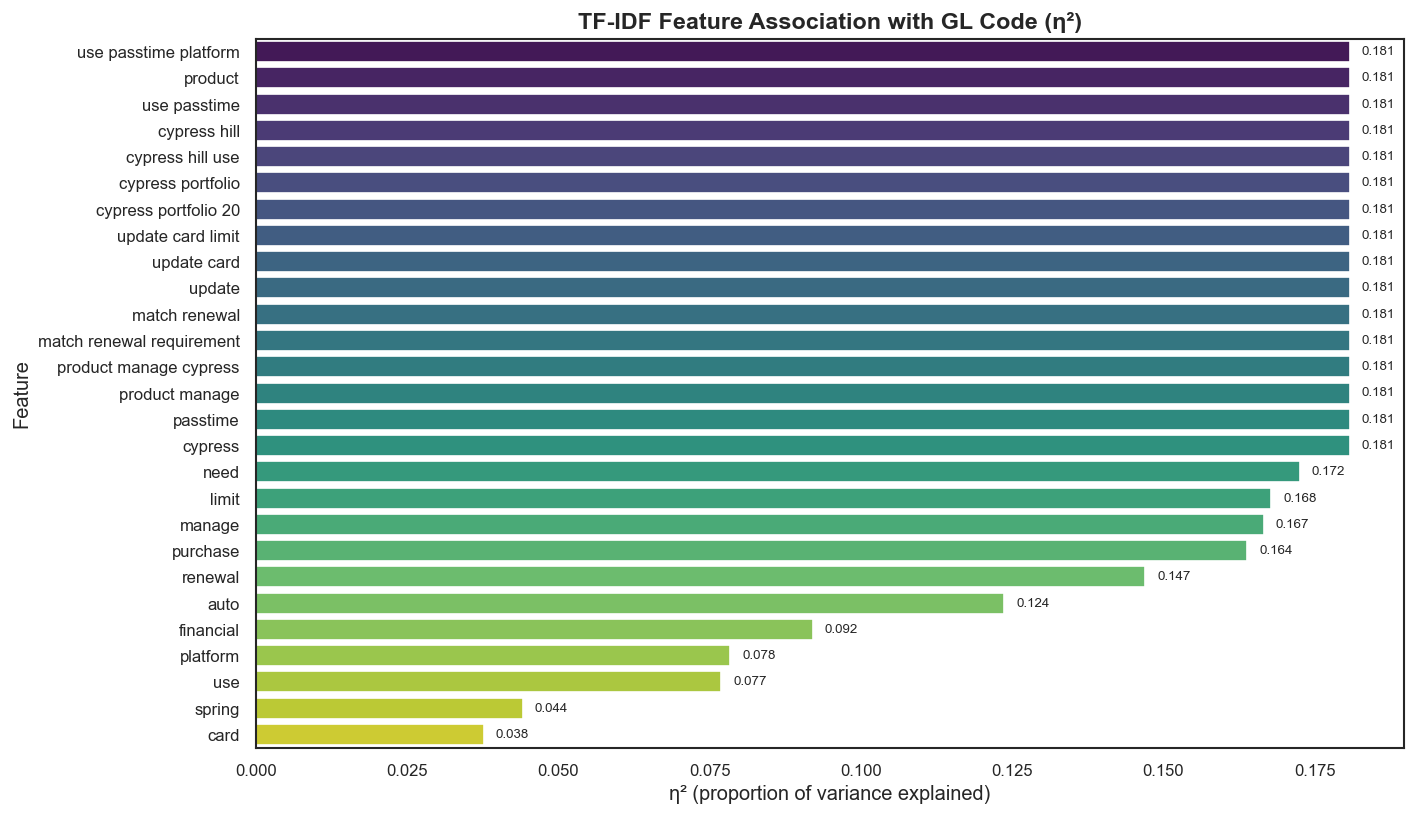

,Feature,η²
0,use passtime platform,0.1808
1,product,0.1808
2,use passtime,0.1808
3,cypress hill,0.1808
4,cypress hill use,0.1808
5,cypress portfolio,0.1808
6,cypress portfolio 20,0.1808
7,update card limit,0.1808
8,update card,0.1808
9,update,0.1808


In [8]:
# ── Eta-squared: one-way ANOVA for each TF-IDF feature vs GL code ───────────
from scipy.stats import f_oneway

groups = [grp[TFIDF_COLS].values for _, grp in df.groupby(TARGET)]
eta2 = {}
for col in TFIDF_COLS:
    grp_vals = [grp[col].values for _, grp in df.groupby(TARGET)]
    ss_total = np.sum((df[col] - df[col].mean()) ** 2)
    if ss_total == 0:
        eta2[col] = 0.0
        continue
    ss_between = sum(len(g) * (g.mean() - df[col].mean()) ** 2 for g in grp_vals)
    eta2[col] = ss_between / ss_total

eta2_df = (pd.DataFrame(list(eta2.items()), columns=["Feature", "η²"])
           .sort_values("η²", ascending=False).reset_index(drop=True))

# bar chart
fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("viridis", n_colors=len(eta2_df))
sns.barplot(data=eta2_df, y="Feature", x="η²", palette=palette, ax=ax)
ax.set_title("TF-IDF Feature Association with GL Code (η²)", fontsize=14, fontweight="bold")
ax.set_xlabel("η² (proportion of variance explained)")
for i, row in eta2_df.iterrows():
    ax.text(row["η²"] + 0.002, i, f'{row["η²"]:.3f}', va="center", fontsize=8)
plt.tight_layout()
plt.show()

# summary table
display(eta2_df.style.format({"η²": "{:.4f}"}).background_gradient(cmap="YlOrRd", subset=["η²"]))

## 4. Per-GL-Code TF-IDF Profile Heatmap

Each cell shows the **z-scored mean TF-IDF weight** for a given feature within a GL code
class. Bright yellow columns highlight features that are distinctly elevated for a
particular class — useful for understanding which n-grams characterise each category.

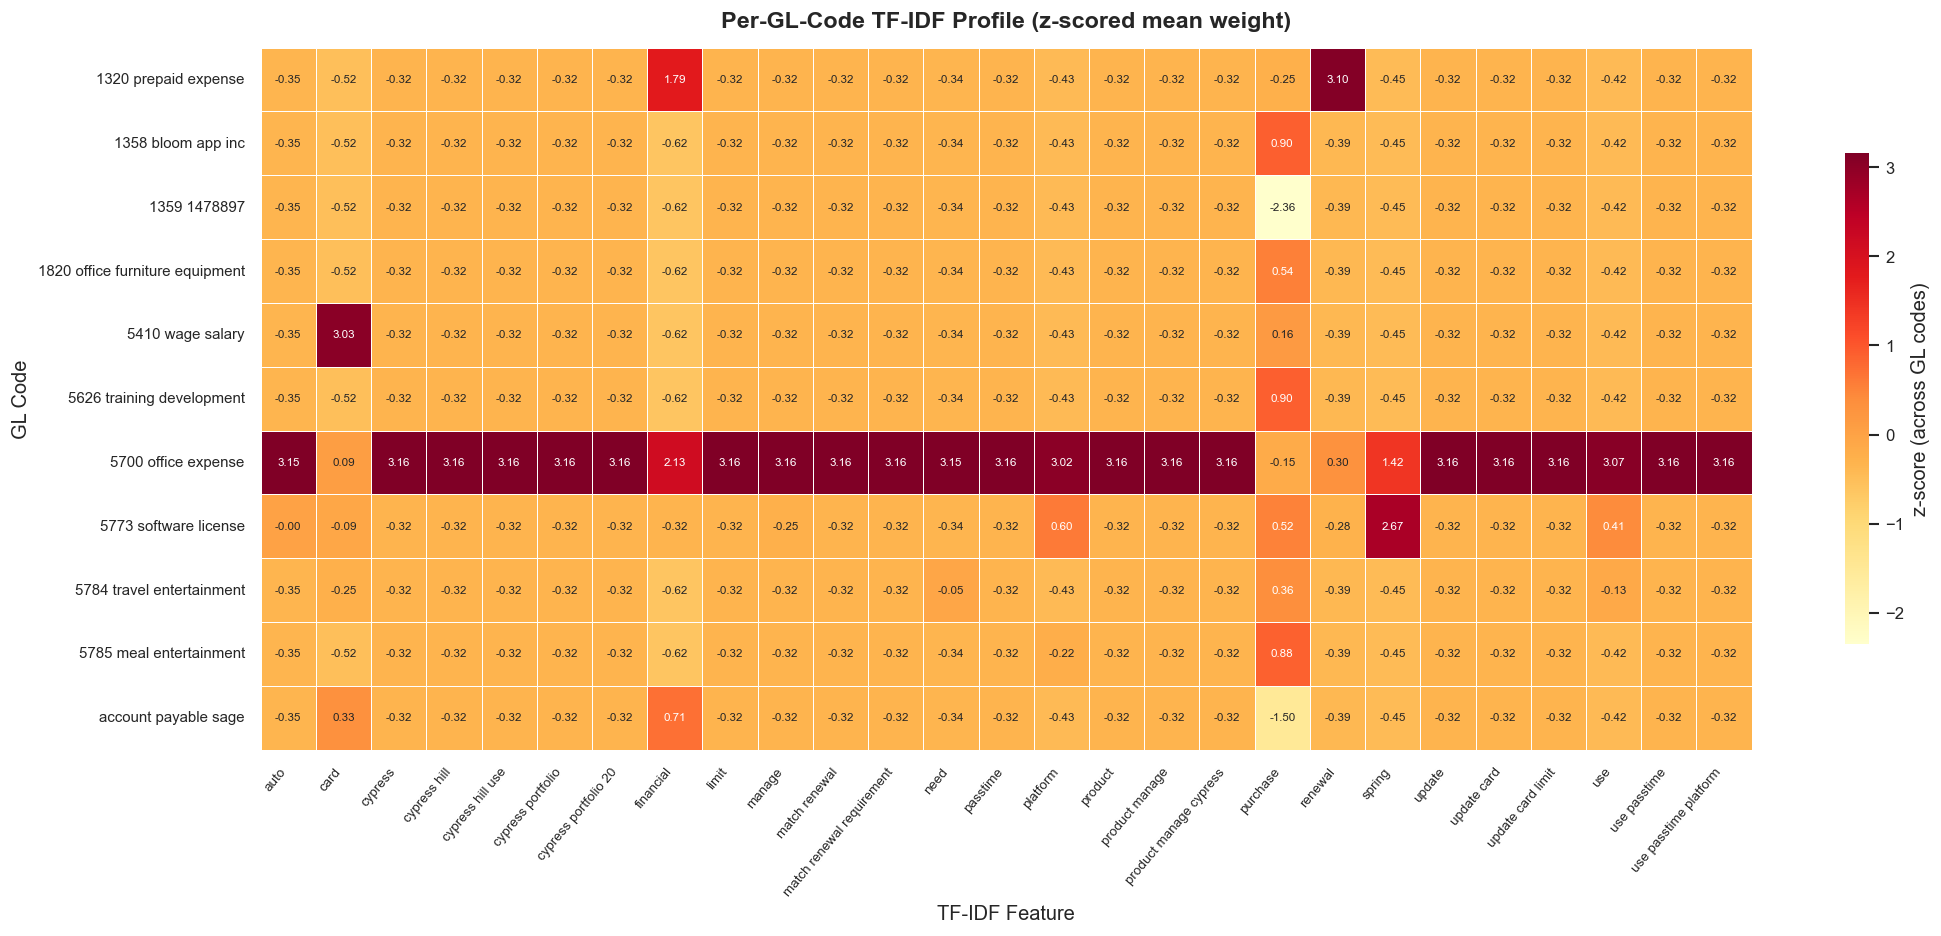

In [9]:
# ── Per-GL-code mean TF-IDF profile (z-scored) ──────────────────────────────
profile = df.groupby(TARGET)[TFIDF_COLS].mean()

# Z-score across GL code classes (row-wise standardisation per feature)
from scipy.stats import zscore
profile_z = profile.apply(zscore, axis=0)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    profile_z, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.3,
    ax=ax, annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7, "label": "z-score (across GL codes)"},
)
ax.set_title("Per-GL-Code TF-IDF Profile (z-scored mean weight)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("GL Code")
ax.set_xlabel("TF-IDF Feature")
plt.xticks(rotation=50, ha="right", fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Top TF-IDF Features — Box Plots by GL Code

Box plots for the **top-8 most discriminative** TF-IDF features (by η²).
Each subplot shows how the feature's TF-IDF weight distributes across GL code classes.

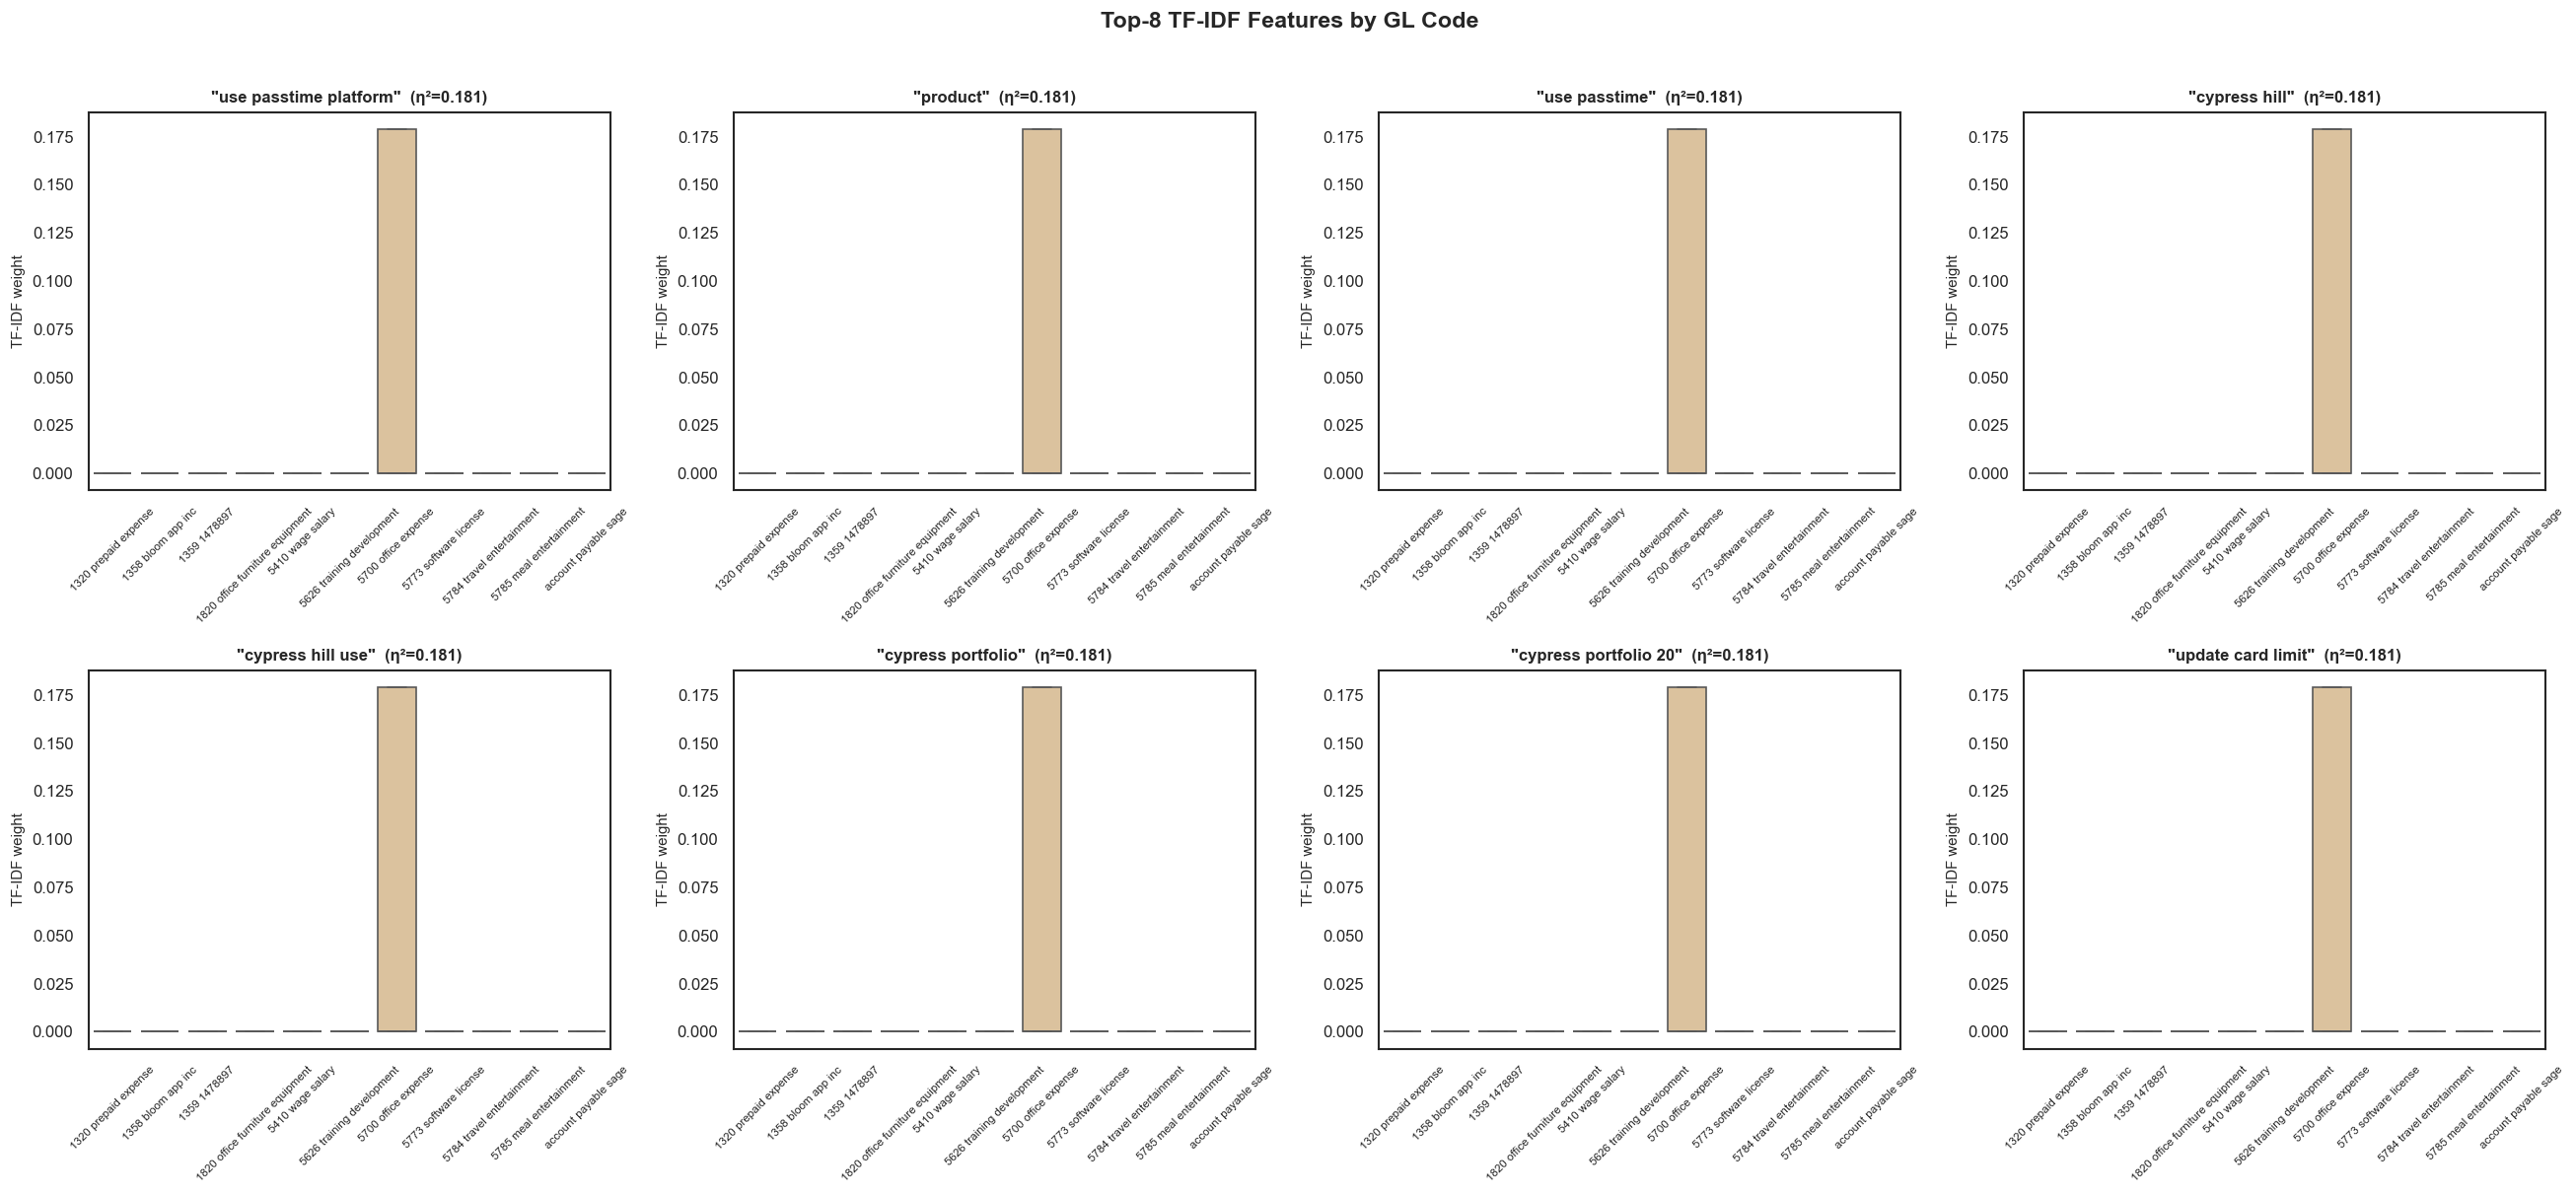

In [10]:
# ── Box plots for top-8 TF-IDF features by η² ──────────────────────────────
top_n = 8
top_features = eta2_df.head(top_n)["Feature"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=False)
for ax, feat in zip(axes.ravel(), top_features):
    sns.boxplot(data=df, x=TARGET, y=feat, ax=ax, palette="Set2", fliersize=2)
    ax.set_title(f'"{feat}"  (η²={eta2[feat]:.3f})', fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.set_ylabel("TF-IDF weight", fontsize=9)

fig.suptitle("Top-8 TF-IDF Features by GL Code", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Violin Plots — Top-4 TF-IDF Features by GL Code

Violin plots reveal the **full density shape** of TF-IDF weights within each GL code,
complementing the box plots above with richer distributional detail.

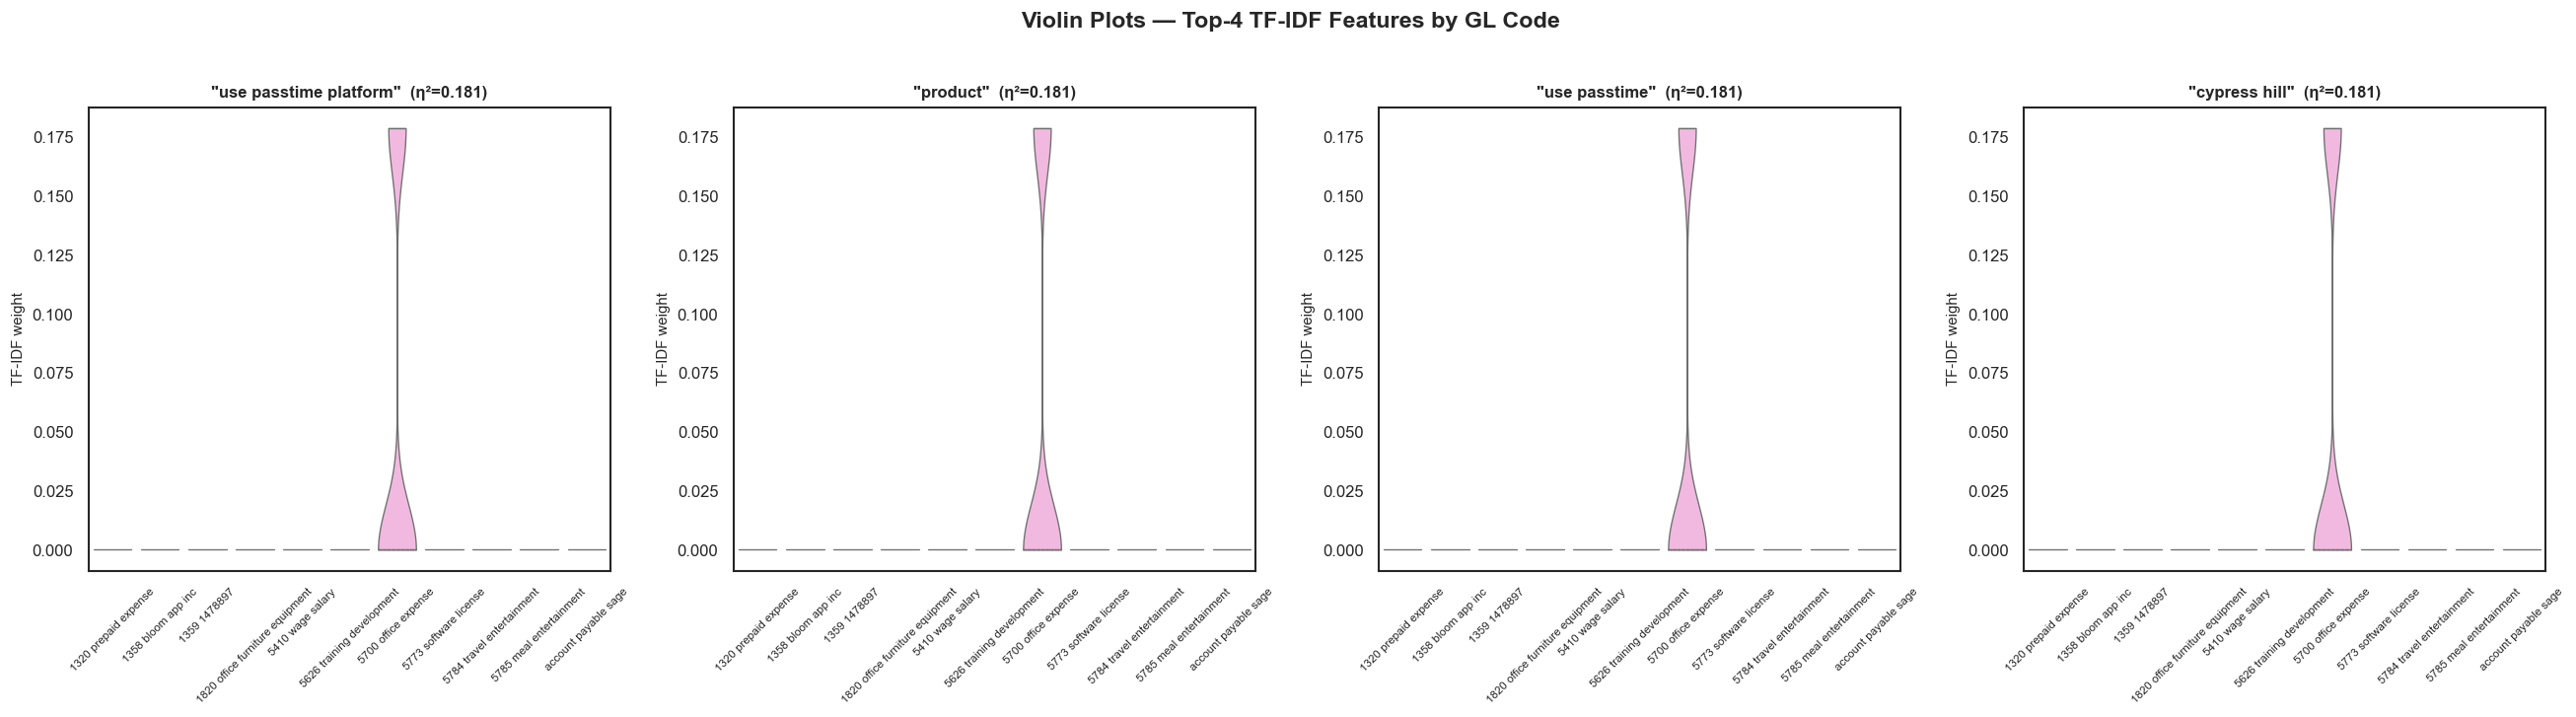

In [11]:
# ── Violin plots for top-4 TF-IDF features ──────────────────────────────────
top4 = eta2_df.head(4)["Feature"].tolist()

fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)
for ax, feat in zip(axes, top4):
    sns.violinplot(data=df, x=TARGET, y=feat, ax=ax, palette="pastel",
                   inner="quartile", cut=0, linewidth=0.8)
    ax.set_title(f'"{feat}"  (η²={eta2[feat]:.3f})', fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.set_ylabel("TF-IDF weight", fontsize=9)

fig.suptitle("Violin Plots — Top-4 TF-IDF Features by GL Code",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Per-GL-Code Top-3 Distinguishing N-grams

For each GL code class, identify the **top-3 TF-IDF features** with the highest
mean weight — i.e. the n-grams most characteristic of that category.

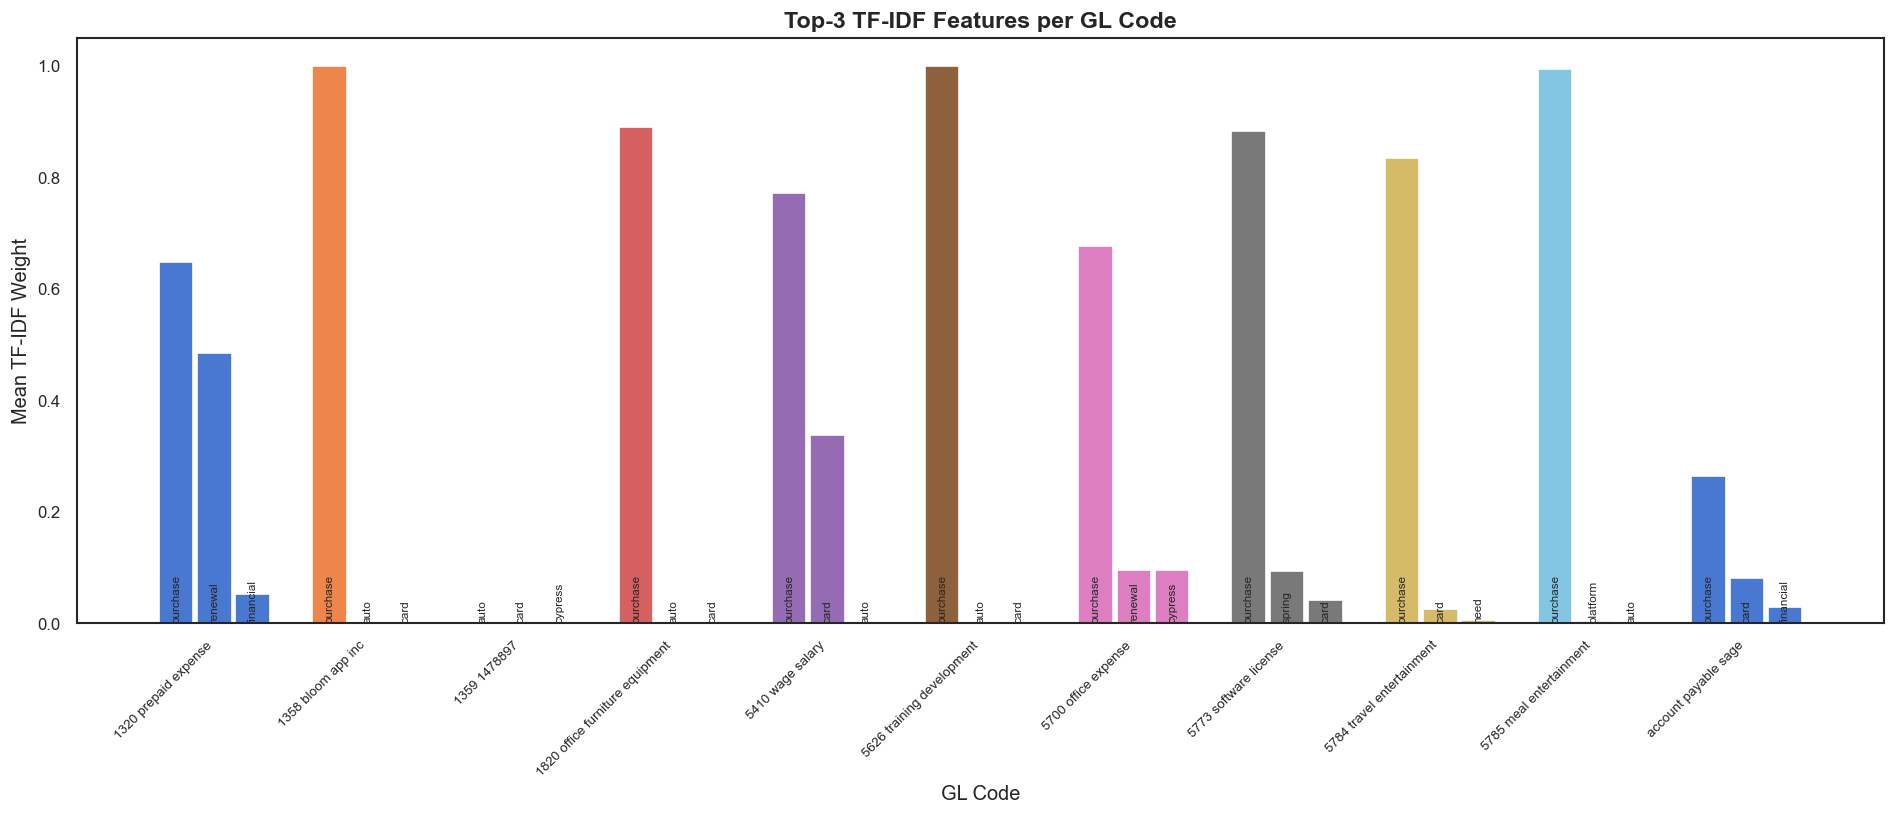

In [12]:
# ── Top-3 distinguishing TF-IDF features per GL code ────────────────────────
profile_raw = df.groupby(TARGET)[TFIDF_COLS].mean()

rows = []
for gl_code in profile_raw.index:
    top3 = profile_raw.loc[gl_code].nlargest(3)
    for rank, (feat, val) in enumerate(top3.items(), 1):
        rows.append({"GL Code": gl_code, "Rank": rank, "Feature": feat, "Mean TF-IDF": val})

top3_df = pd.DataFrame(rows)
display(top3_df.pivot_table(index="GL Code", columns="Rank",
                            values=["Feature", "Mean TF-IDF"], aggfunc="first")
        .style.format({"Mean TF-IDF": "{:.4f}"}, na_rep="—"))

# grouped bar chart
fig, ax = plt.subplots(figsize=(16, 7))
for i, gl in enumerate(profile_raw.index):
    subset = top3_df[top3_df["GL Code"] == gl]
    x_positions = [i * 4 + j for j in range(len(subset))]
    bars = ax.bar(x_positions, subset["Mean TF-IDF"], width=0.9, label=str(gl) if i == 0 else "")
    for xp, feat in zip(x_positions, subset["Feature"]):
        ax.text(xp, 0.001, feat, rotation=90, ha="center", va="bottom", fontsize=7)

ax.set_xticks([i * 4 + 1 for i in range(len(profile_raw.index))])
ax.set_xticklabels([str(g) for g in profile_raw.index], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("GL Code")
ax.set_ylabel("Mean TF-IDF Weight")
ax.set_title("Top-3 TF-IDF Features per GL Code", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Unified Feature Importance Ranking

A single bar chart ranking all 27 TF-IDF features by their **η² association** with GL code,
coloured by the GL code class where each feature has its highest mean weight.
This gives a quick summary of which n-grams matter most and which class they primarily serve.

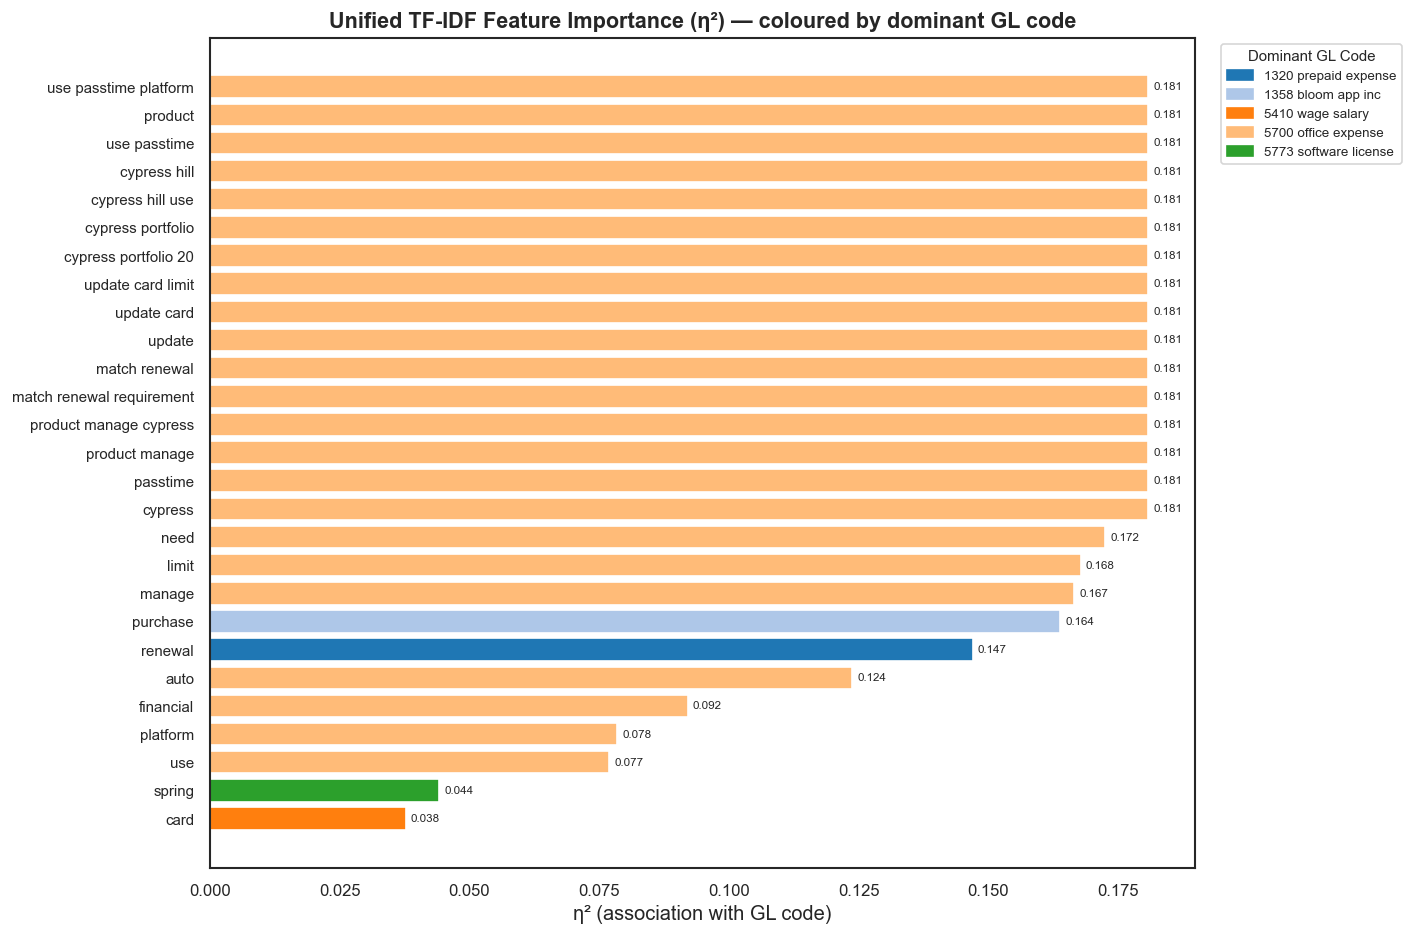

In [13]:
# ── Unified importance ranking coloured by dominant GL code ──────────────────
dominant_gl = profile_raw.idxmax(axis=0)  # GL code with highest mean for each feature

ranking = eta2_df.copy()
ranking["Dominant GL Code"] = ranking["Feature"].map(dominant_gl).astype(str)

fig, ax = plt.subplots(figsize=(12, 8))
gl_codes_unique = sorted(ranking["Dominant GL Code"].unique())
palette_map = dict(zip(gl_codes_unique, sns.color_palette("tab20", len(gl_codes_unique))))
colors = ranking["Dominant GL Code"].map(palette_map)

bars = ax.barh(ranking["Feature"], ranking["η²"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("η² (association with GL code)")
ax.set_title("Unified TF-IDF Feature Importance (η²) — coloured by dominant GL code",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)

# legend
from matplotlib.patches import Patch
handles = [Patch(color=palette_map[g], label=g) for g in gl_codes_unique]
ax.legend(handles=handles, title="Dominant GL Code", bbox_to_anchor=(1.02, 1),
          loc="upper left", fontsize=8, title_fontsize=9)

for i, row in ranking.iterrows():
    ax.text(row["η²"] + 0.001, i, f'{row["η²"]:.3f}', va="center", fontsize=7)

plt.tight_layout()
plt.show()

## 9. Ablation Study — Impact of TF-IDF (Aggregated Text) on Pipeline Performance

The full pipeline was run twice with **identical CatBoost hyperparameters** and deterministic rules,
varying only whether the 27 TF-IDF features (derived from `aggregated_text`) were included.

### Configuration
- **Model**: CatBoost (500 estimators, max_depth=5, lr≈0.193)
- **Deterministic layer**: ON (covers 12 GL codes, 95 test rows)
- **Train/test split**: 99/1 (training on full data, small held-out sanity check)
- **Evaluation**: Held-out test file (`test_data.csv`, 398 rows)

---

### Overall Test-Set Metrics

| Metric | **With TF-IDF** (50 features) | **Without TF-IDF** (23 features) | Δ |
|---|---|---|---|
| **Features** | 23 manual + 27 TF-IDF = **50** | 23 manual only | −27 features |
| **Test Accuracy** | **0.8769** | 0.8367 | **−4.02 pp** |
| **Test F1 (weighted)** | **0.8560** | 0.8196 | **−3.64 pp** |
| **Test F1 (macro)** | 0.6467 | **0.6541** | +0.74 pp |

### ML-Only Performance (excluding deterministic rows)

| Metric | **With TF-IDF** | **Without TF-IDF** | Δ |
|---|---|---|---|
| **ML correct** | 255 / 303 (**84.16%**) | 239 / 303 (78.88%) | **−5.28 pp** |
| **Deterministic correct** | 94 / 95 (98.95%) | 94 / 95 (98.95%) | 0 |

### Per-GL-Code F1 Comparison (selected classes)

| GL Code | F1 **With TF-IDF** | F1 **Without TF-IDF** | Δ |
|---|---|---|---|
| 5700 office expense | 0.89 | 0.87 | −0.02 |
| 5773 software license | 0.90 | 0.82 | **−0.08** |
| 5784 travel entertainment | 0.80 | **0.90** | +0.10 |
| 5785 meal entertainment | **0.14** | **0.54** | **+0.40** |
| account payable sage | **0.85** | 0.61 | **−0.24** |
| 5450 hr recruiting | 0.95 | 0.95 | 0 |

---

### Key Takeaways

1. **Overall accuracy drops ~4 pp without TF-IDF**, confirming that text features contribute meaningfully to the model — especially for the ML-handled classes.

2. **Macro F1 is roughly flat** (+0.74 pp without TF-IDF), which suggests the TF-IDF features mainly help the **majority classes** (5700 office expense, 5773 software license, account payable sage). Minority classes see mixed effects.

3. **Biggest winner from TF-IDF**: `account payable sage` (F1: 0.61 → 0.85, +0.24) — the text n-grams like "financial", "limit" strongly distinguish this class.

4. **Biggest loser from TF-IDF**: `5785 meal entertainment` (F1: 0.54 → 0.14, −0.40) — the TF-IDF features may introduce noise for this small class (12 test samples), where manual features (payee keywords) work better alone.

5. **Deterministic layer is unaffected** (94/95 = 98.95% in both runs), as expected — it relies on rule-based matching, not ML features.

6. **Recommendation**: Keep TF-IDF features for production — the +4 pp accuracy and +5.3 pp ML-only accuracy outweigh the minority-class regressions, which should be addressed through class-specific tuning or augmentation rather than removing text features.

## 10. Correlation-Based Feature Pruning Analysis

How many of the 27 TF-IDF features are **redundant** at various correlation thresholds?
We greedily remove features: for each highly-correlated pair (|r| ≥ threshold), drop the one
with lower η² (less discriminative for GL code).

Greedy correlation-based pruning (drop feature with lower η² from each correlated pair)



Threshold (|r|),Dropped,Kept,Dropped Features
0.900000,18,9,"cypress, cypress hill use, cypress portfolio, cypress portfolio 20, limit, manage, match renewal, match renewal requirement, need, passtime, product, product manage, product manage cypress, update, update card, update card limit, use passtime, use passtime platform"
0.850000,19,8,"auto, cypress, cypress hill use, cypress portfolio, cypress portfolio 20, limit, manage, match renewal, match renewal requirement, need, passtime, product, product manage, product manage cypress, update, update card, update card limit, use passtime, use passtime platform"
0.800000,19,8,"auto, cypress, cypress hill use, cypress portfolio, cypress portfolio 20, limit, manage, match renewal, match renewal requirement, need, passtime, product, product manage, product manage cypress, update, update card, update card limit, use passtime, use passtime platform"
0.750000,21,6,"auto, cypress, cypress hill use, cypress portfolio, cypress portfolio 20, limit, manage, match renewal, match renewal requirement, need, passtime, platform, product, product manage, product manage cypress, renewal, update, update card, update card limit, use passtime, use passtime platform"
0.700000,23,4,"auto, cypress, cypress hill use, cypress portfolio, cypress portfolio 20, limit, manage, match renewal, match renewal requirement, need, passtime, platform, product, product manage, product manage cypress, purchase, renewal, update, update card, update card limit, use, use passtime, use passtime platform"
0.600000,24,3,"auto, cypress, cypress hill use, cypress portfolio, cypress portfolio 20, financial, limit, manage, match renewal, match renewal requirement, need, passtime, platform, product, product manage, product manage cypress, purchase, renewal, update, update card, update card limit, use, use passtime, use passtime platform"
0.500000,25,2,"auto, card, cypress, cypress hill use, cypress portfolio, cypress portfolio 20, financial, limit, manage, match renewal, match renewal requirement, need, passtime, platform, product, product manage, product manage cypress, purchase, renewal, update, update card, update card limit, use, use passtime, use passtime platform"



Detail at |r| ≥ 0.75 threshold:

  Dropped (21): ['auto', 'cypress', 'cypress hill use', 'cypress portfolio', 'cypress portfolio 20', 'limit', 'manage', 'match renewal', 'match renewal requirement', 'need', 'passtime', 'platform', 'product', 'product manage', 'product manage cypress', 'renewal', 'update', 'update card', 'update card limit', 'use passtime', 'use passtime platform']
  Kept    (6): ['card', 'cypress hill', 'financial', 'purchase', 'spring', 'use']

  Correlated pairs triggering removal (|r| ≥ 0.75):
    use passtime                   ↔ use passtime platform           |r|=1.000   → ✗ use passtime (η²=0.1808)
    cypress portfolio 20           ↔ update                          |r|=1.000   → ✗ cypress portfolio 20 (η²=0.1808)
    cypress portfolio 20           ↔ product manage cypress          |r|=1.000   → ✗ cypress portfolio 20 (η²=0.1808)
    cypress portfolio 20           ↔ product manage                  |r|=1.000   → ✗ cypress portfolio 20 (η²=0.1808)
    cypress port

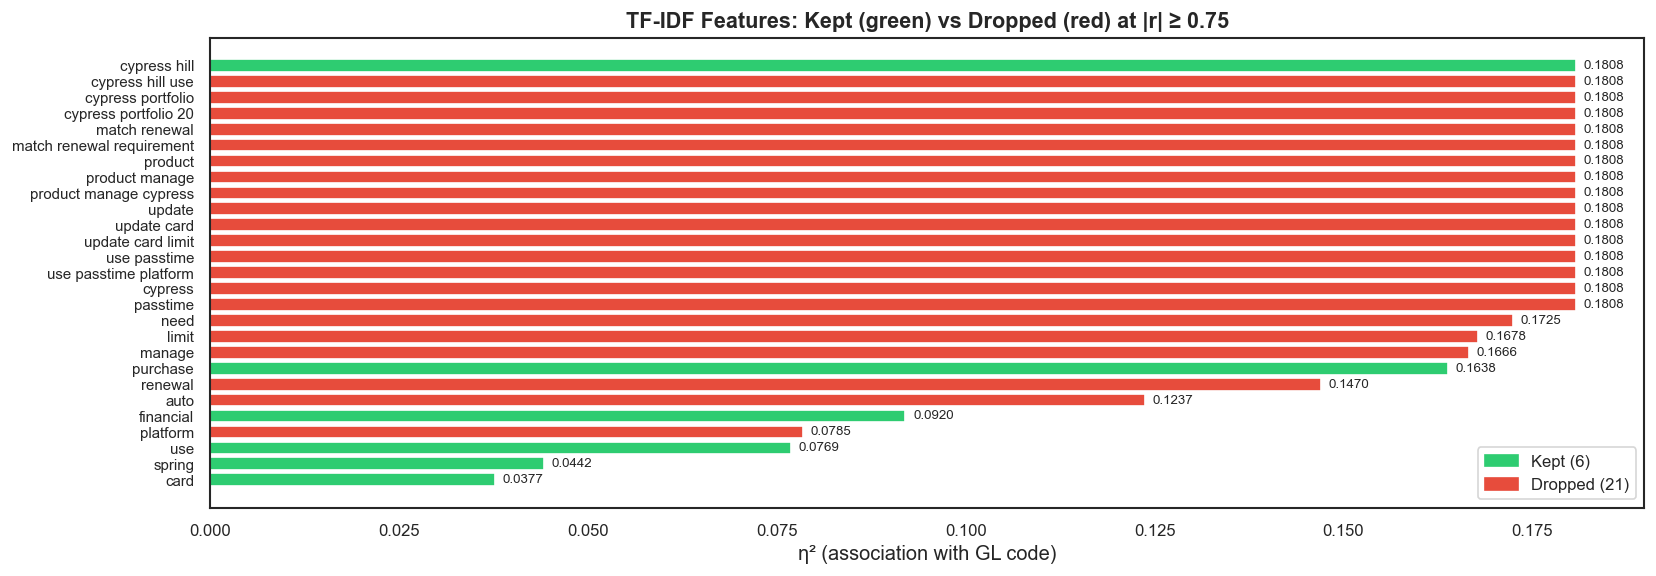

In [4]:
# ── Correlation-based pruning at various thresholds ─────────────────────────
from scipy.stats import f_oneway

corr = df[TFIDF_COLS].corr().abs()

# Compute η² for each feature (needed to decide which to keep)
eta2 = {}
for col in TFIDF_COLS:
    grp_vals = [grp[col].values for _, grp in df.groupby("gl_code")]
    ss_total = np.sum((df[col] - df[col].mean()) ** 2)
    if ss_total == 0:
        eta2[col] = 0.0
        continue
    ss_between = sum(len(g) * (g.mean() - df[col].mean()) ** 2 for g in grp_vals)
    eta2[col] = ss_between / ss_total


def greedy_prune(corr_matrix, eta2_dict, threshold):
    """Greedily remove the less-discriminative feature from each pair with |r| >= threshold."""
    to_drop = set()
    features = list(corr_matrix.columns)
    for i in range(len(features)):
        if features[i] in to_drop:
            continue
        for j in range(i + 1, len(features)):
            if features[j] in to_drop:
                continue
            if corr_matrix.iloc[i, j] >= threshold:
                # Drop the one with lower η²
                if eta2_dict[features[i]] < eta2_dict[features[j]]:
                    to_drop.add(features[i])
                    break  # feature i is dropped, move on
                else:
                    to_drop.add(features[j])
    return to_drop


thresholds = [0.90, 0.85, 0.80, 0.75, 0.70, 0.60, 0.50]
results = []
for t in thresholds:
    dropped = greedy_prune(corr, eta2, t)
    kept = [f for f in TFIDF_COLS if f not in dropped]
    results.append({
        "Threshold (|r|)": t,
        "Dropped": len(dropped),
        "Kept": len(kept),
        "Dropped Features": ", ".join(sorted(dropped)) or "—",
    })

results_df = pd.DataFrame(results)
print("Greedy correlation-based pruning (drop feature with lower η² from each correlated pair)\n")
display(results_df.style.set_properties(**{"text-align": "left"}).hide(axis="index"))

# ── Detail at threshold = 0.75 ──
print("\n" + "=" * 70)
print("Detail at |r| ≥ 0.75 threshold:")
print("=" * 70)
dropped_075 = greedy_prune(corr, eta2, 0.75)
kept_075 = [f for f in TFIDF_COLS if f not in dropped_075]
print(f"\n  Dropped ({len(dropped_075)}): {sorted(dropped_075)}")
print(f"  Kept    ({len(kept_075)}): {kept_075}")

# Show which pairs caused the drops
print("\n  Correlated pairs triggering removal (|r| ≥ 0.75):")
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = corr.where(mask_upper).stack().reset_index()
pairs.columns = ["Feature A", "Feature B", "|r|"]
pairs = pairs[pairs["|r|"] >= 0.75].sort_values("|r|", ascending=False)
for _, row in pairs.iterrows():
    a, b, r = row["Feature A"], row["Feature B"], row["|r|"]
    dropped_one = "✗ " + (a if a in dropped_075 else b)
    kept_one = "✓ " + (b if a in dropped_075 else a)
    print(f"    {a:30s} ↔ {b:30s}  |r|={r:.3f}   → {dropped_one} (η²={eta2[a if a in dropped_075 else b]:.4f})")

# ── Visual: features kept vs dropped ──
fig, ax = plt.subplots(figsize=(14, 5))
eta2_sorted = sorted(eta2.items(), key=lambda x: x[1], reverse=True)
names = [f for f, _ in eta2_sorted]
values = [v for _, v in eta2_sorted]
colors = ["#2ecc71" if f in kept_075 else "#e74c3c" for f in names]
ax.barh(names, values, color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("η² (association with GL code)")
ax.set_title("TF-IDF Features: Kept (green) vs Dropped (red) at |r| ≥ 0.75",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2ecc71", label=f"Kept ({len(kept_075)})"),
                   Patch(color="#e74c3c", label=f"Dropped ({len(dropped_075)})")],
          loc="lower right", fontsize=10)
for i, (name, val) in enumerate(zip(names, values)):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()